In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress
import matplotlib.ticker as mticker

In [2]:
cameras = {"St.David": 7, "Contention": 6, "Fairbank": 1, "Boquillas": 8, "CharlestonMesquite": 2, "Moson": 3, "Hunter": 4, "Hereford": 5}

flow = pd.read_csv(r"../Data/USPPFlowMonitoring2006_2025.csv")
flow["Date"] = pd.to_datetime(flow["Date"])
flow["Camera"] = flow["Site"].map(cameras)
et = pd.read_csv(r"../Data/Jawad_ET/J.csv")
et["date"] = pd.to_datetime(et["date"])
et = et.rename(columns = {"date": "Date"})
climate = pd.read_csv(r"../Data/Daymet2006_2024.csv")
climate["date"] = pd.to_datetime(climate["date"])
climate = climate.rename(columns = {"date": "Date", "camera": "Camera", "site": "Site"})

In [3]:
hydro = pd.merge(flow, et, left_on = ["Date", "Camera", "Site"], right_on = ["Date", "Camera", "Site"], how = "inner")
hydro = pd.merge(hydro, climate, left_on = ["Date", "Camera", "Site"], right_on = ["Date", "Camera", "Site"], how = "inner")
hydro["FP"] = hydro["Flow Code"].replace({2: 1})

In [4]:
precip = hydro.groupby(["WY", "Season"]).agg({"prcp": "sum", "FP": "mean"}).reset_index()
wide = precip.pivot(index = "WY", columns = "Season", values = ["prcp", "FP"])
wide.columns = [f"{col[0]}_{int(col[1])}" for col in wide.columns]
wide = wide.reset_index()
wide["WY"] = wide["WY"].astype(int)

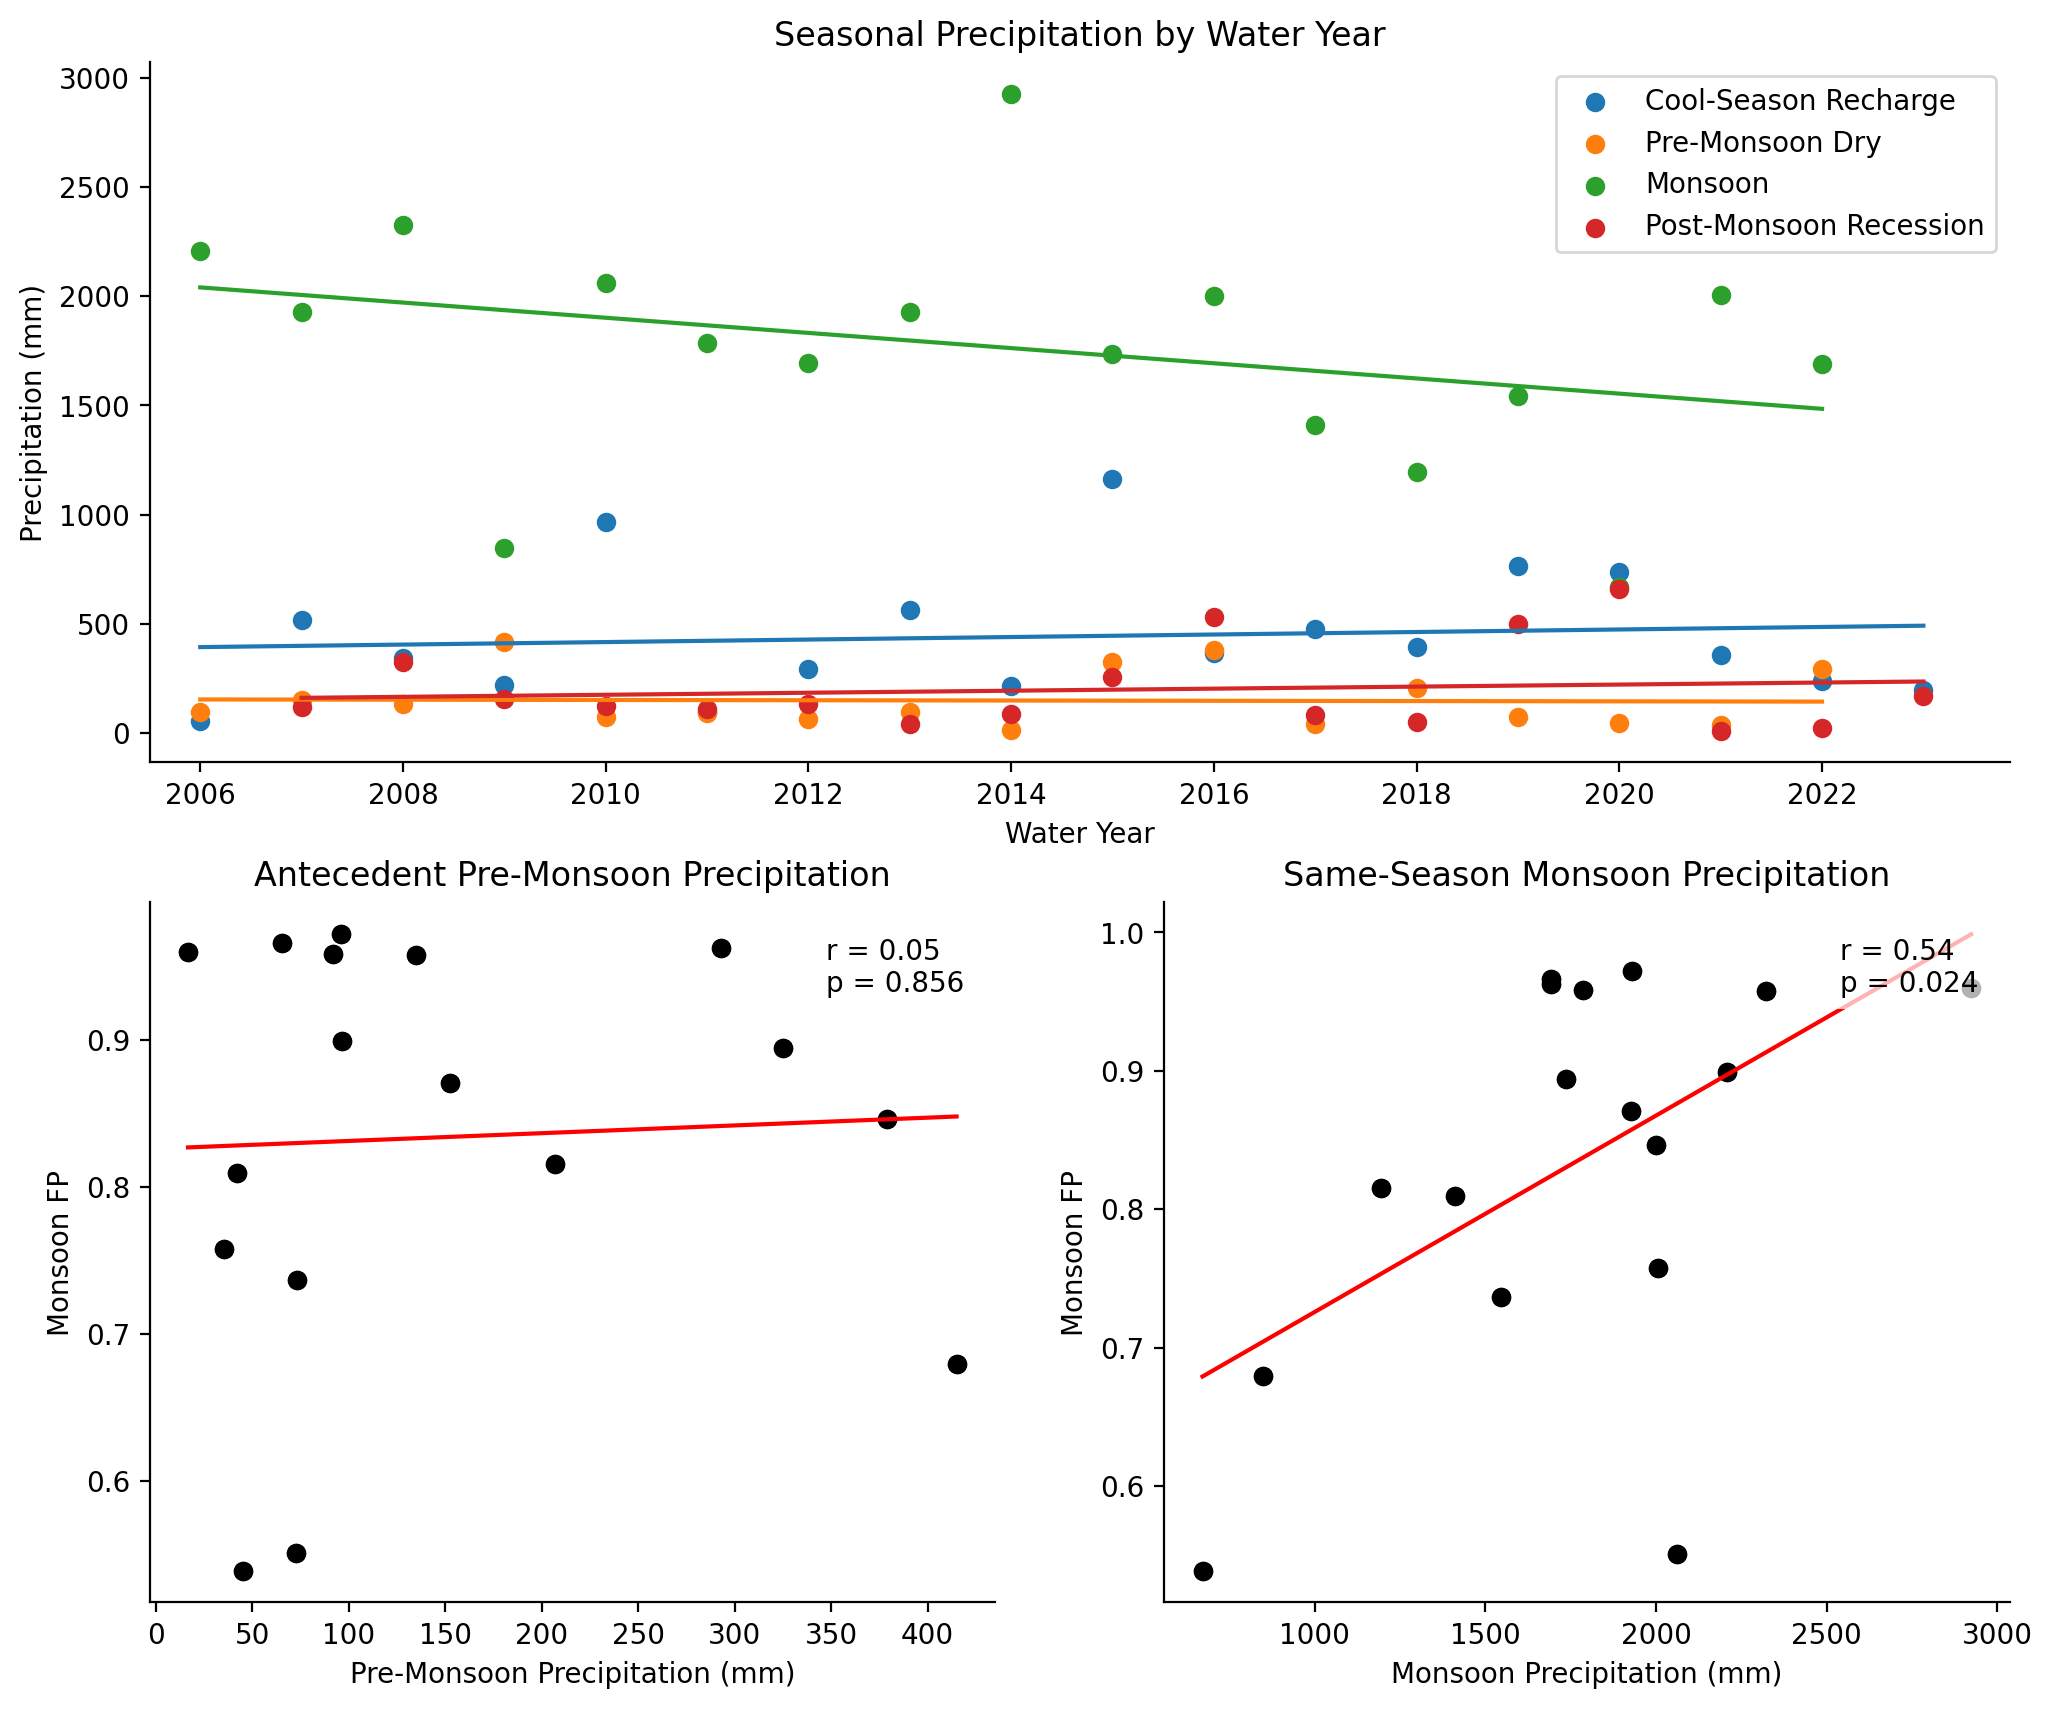

In [5]:
fig = plt.figure(figsize = (12, 10))

ax1 = plt.subplot2grid((2, 2), (0, 0), colspan = 2)

def add_season(ax, x, y, label, color):
    mask = ~(x.isna() | y.isna())
    x_clean = x[mask]
    y_clean = y[mask]
    ax.scatter(x_clean, y_clean, label = label, color = color)
    slope, intercept, r, p, stderr = linregress(x_clean, y_clean)
    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color = color, linestyle = "-")

add_season(ax1, wide["WY"], wide["prcp_1"], "Cool-Season Recharge", "tab:blue")
add_season(ax1, wide["WY"], wide["prcp_2"], "Pre-Monsoon Dry", "tab:orange")
add_season(ax1, wide["WY"], wide["prcp_3"], "Monsoon", "tab:green")
add_season(ax1, wide["WY"], wide["prcp_4"], "Post-Monsoon Recession", "tab:red")

ax1.set_title("Seasonal Precipitation by Water Year")
ax1.set_xlabel("Water Year")
ax1.xaxis.set_major_locator(mticker.MaxNLocator(integer = True))
ax1.set_xlim(left = 2005.5)
ax1.set_ylabel("Precipitation (mm)")
ax1.legend()
ax1.spines[["top", "right"]].set_visible(False)

def add_regression(ax, x, y):
    mask = ~(x.isna() | y.isna())
    x_clean = x[mask]
    y_clean = y[mask]
    ax.scatter(x_clean, y_clean, color='black')
    slope, intercept, r, p, stderr = linregress(x_clean, y_clean)
    x_line = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_line = slope * x_line + intercept
    ax.plot(x_line, y_line, color = "red")
    ax.text(
        0.8, 0.95,
        f"r = {r:.2f}\np = {p:.3f}",
        transform = ax.transAxes,
        ha = "left", va = "top",
        bbox = dict(facecolor = "white", alpha = 0.7, edgecolor = "none")
    )

ax2 = plt.subplot2grid((2, 2), (1, 0))
ax2.scatter(wide["prcp_2"], wide["FP_3"], color='black')
add_regression(ax2, wide["prcp_2"], wide["FP_3"])
ax2.set_title("Antecedent Pre-Monsoon Precipitation")
ax2.set_xlabel("Pre-Monsoon Precipitation (mm)")
ax2.set_ylabel("Monsoon FP")
ax2.spines[["top", "right"]].set_visible(False)

ax3 = plt.subplot2grid((2, 2), (1, 1))
add_regression(ax3, wide["prcp_3"], wide["FP_3"])
ax3.scatter(wide["prcp_3"], wide["FP_3"], color='black')
ax3.set_title("Same-Season Monsoon Precipitation")
ax3.set_xlabel("Monsoon Precipitation (mm)")
ax3.set_ylabel("Monsoon FP")
ax3.spines[["top", "right"]].set_visible(False)

%config InlineBackend.figure_format = "retina"
# plt.savefig("../Figures/precip_fp_seasons.png", format = "png", dpi = 300, bbox_inches = "tight")

In [6]:
et_agg = hydro.groupby(["Date", "WY", "Season"])["ET"].mean().reset_index()
et_agg = et_agg.groupby(["WY", "Season"])["ET"].sum().reset_index()
et_wide = et_agg.pivot(index = "WY", columns = "Season", values = "ET")
et_wide.columns = [f"ET_{c}" for c in et_wide.columns]
et_wide = et_wide.reset_index()

In [7]:
wide = pd.merge(wide, et_wide, on = "WY", how = "inner")

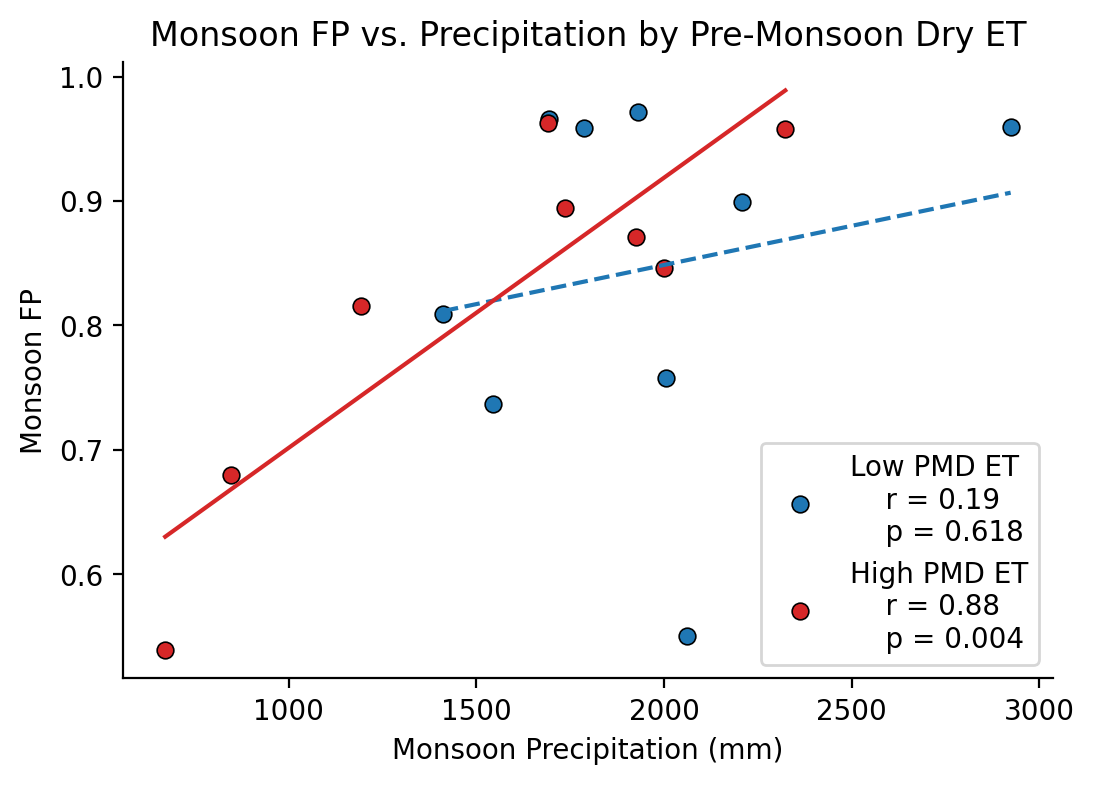

In [ ]:
thres = wide["ET_2"].median()

lowET = wide[wide["ET_2"] <= thres]
highET = wide[wide["ET_2"] > thres]

fig, ax = plt.subplots(figsize = (6, 4))

x_low = lowET["prcp_3"]
y_low = lowET["FP_3"]

slope, intercept, r, p, stderr = linregress(x_low, y_low)
x_line = np.linspace(x_low.min(), x_low.max(), 100)
ax.plot(x_line, slope*x_line + intercept, color = "tab:blue", linestyle = "--")
ax.scatter(x_low, y_low, color = "tab:blue", edgecolor = "black", linewidth = 0.6, label = f"Low PMD ET\n    r = {r:.2f}\n    p = {p:.3f}")

x_high = highET["prcp_3"]
y_high = highET["FP_3"]
slope, intercept, r, p, stderr = linregress(x_high, y_high)
x_line = np.linspace(x_high.min(), x_high.max(), 100)
ax.plot(x_line, slope*x_line + intercept, color = "tab:red", linestyle = "-")
ax.scatter(x_high, y_high, color = "tab:red", edgecolor = "black", linewidth = 0.6, label = f"High PMD ET\n    r = {r:.2f}\n    p = {p:.3f}")

ax.set_title("Monsoon FP vs. Precipitation by Pre-Monsoon Dry ET")
ax.set_xlabel("Monsoon Precipitation (mm)")
ax.set_ylabel("Monsoon FP")
ax.legend(loc = "lower right")
ax.spines[["top", "right"]].set_visible(False)

%config InlineBackend.figure_format = "retina"
# plt.savefig("../Figures/precip_et_fp.png", format = "png", dpi = 300, bbox_inches = "tight")